# W5 — Biến đổi, giảm chiều và tích hợp dữ liệu 🌦️
## Dự báo thời tiết Hà Nội • NASA POWER

Notebook riêng cho W5, dựa trên **W5 – Transformation, reduction & integration**, 36 trang (số slide 70–105), và schema của dự án hiện tại.

**Cách chạy:** đặt notebook trong thư mục gốc hoặc `notebooks/` của `Weather-Prediction-ML`, chọn kernel venv rồi **Run All**. Nếu dùng nơi khác, sửa `PROJECT_ROOT`. Không cần chạy notebook W4 trước: mặc định đọc raw và thực hiện kiểm tra cơ bản. Có thể chọn đầu ra W4 bằng `INPUT_MODE='w4'`.

**Phạm vi:** dùng toàn bộ dữ liệu để học cách biến đổi, so sánh và xuất dữ liệu phục vụ EDA. Không tạo train/test, không huấn luyện mô hình dự báo, không có điểm số đánh giá. Scaler, imputer, PCA và ngưỡng tương quan trong notebook chỉ là kết quả khám phá toàn bộ dữ liệu; khi bước sang mô hình hóa phải fit lại trong từng tập huấn luyện theo thời gian.

| Nội dung slide | Phần thực hiện |
|---|---|
| Trang 7–12: scaling, phân phối lệch | So sánh 3 scaler; log1p, sqrt, Yeo–Johnson |
| Trang 13–16: binning, encoding | cut/qcut, one-hot, ordinal; sin/cos cho biến chu kỳ |
| Trang 19–22: reduction | Cột hằng, tương quan, PCA; tổng hợp ngày, cửa sổ thời gian |
| Trang 24–32: integration | concat, merge có validate, nguồn gốc, tỷ lệ khớp, melt/pivot |
| Trang 33–35: Pipeline, bài tập | Pipeline + ColumnTransformer; xuất processed, dictionary và log |

**Không áp dụng máy móc:** không xóa mưa lớn chỉ vì là outlier, không coi hướng gió là số tuyến tính, không lấy PCA làm đặc trưng mặc định. Không tạo lỗi giả để minh họa làm sạch.


In [1]:
# Chạy một lần nếu kernel thiếu thư viện (bỏ dấu #):
# %pip install pandas numpy matplotlib scikit-learn ipykernel
# Cài scikit-learn, nhưng import bằng tên sklearn.


### 1. Cấu hình
`INPUT_MODE='raw'` cho quy trình từ raw → processed bằng Run All. Chọn `'w4'` để tiếp nối file đã kiểm tra của W4, đồng thời mang theo nhật ký W4. Các đầu ra W5 cùng tên sẽ được ghi đè khi chạy lại; raw và đầu ra W4 giữ nguyên.


In [2]:
from pathlib import Path
from datetime import timezone, timedelta
import json, hashlib, unicodedata, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.preprocessing import (MinMaxScaler, StandardScaler, RobustScaler,
                                   PowerTransformer, OneHotEncoder)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, TransformerMixin

PROJECT_ROOT = None  # Ví dụ Path(r'C:\Users\ameli\OneDrive\Documents\Weather-Prediction-ML')
INPUT_MODE = 'raw'   # 'raw' hoặc 'w4'
RAW_REL = Path('data/raw/nasa_power/hanoi_hourly_20230101_20241231.csv')
if PROJECT_ROOT is None:
    ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/RAW_REL).exists()), None)
    if ROOT is None:
        raise FileNotFoundError('Không tìm thấy dự án. Sửa PROJECT_ROOT ở cell này.')
else:
    ROOT = Path(PROJECT_ROOT).expanduser().resolve()
RAW_PATH = ROOT/RAW_REL
assert INPUT_MODE in {'raw','w4'}
INPUT = RAW_PATH if INPUT_MODE == 'raw' else ROOT/'data/cleaned/w4/weather_w4_validated.csv'
META_PATH = RAW_PATH.with_suffix('.metadata.json')
OUT = ROOT/'data/processed/w5'
REPORT = ROOT/'reports/w5'
EXTERNAL_PATH = None  # Tùy chọn: Path tới CSV nguồn thời tiết độc lập, xem mục 5.
EXTERNAL_SOURCE_NAME = ''  # Điền tên/URL nguồn khi dùng EXTERNAL_PATH.
FEATURES = ['T2M','PRECTOTCORR','RH2M','PS','WS2M','WD2M','ALLSKY_SFC_SW_DWN']
LINEAR = [c for c in FEATURES if c != 'WD2M']
VN_TZ = timezone(timedelta(hours=7))
RANDOM_STATE = 42
plt.rcParams.update({'figure.figsize':(11,4), 'axes.grid':True, 'grid.alpha':.2})
pd.set_option('display.max_columns',25)
raw = pd.read_csv(INPUT)
meta = json.loads(META_PATH.read_text(encoding='utf-8')) if META_PATH.exists() else {}
input_hash = hashlib.sha256(INPUT.read_bytes()).hexdigest()
raw_hash = hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()
print('Đầu vào:', INPUT.relative_to(ROOT), '|', raw.shape)
display(raw.head(3))


Đầu vào: data/raw/nasa_power/hanoi_hourly_20230101_20241231.csv | (17544, 11)


,timestamp,city,latitude,longitude,T2M,PRECTOTCORR,RH2M,PS,WS2M,WD2M,ALLSKY_SFC_SW_DWN
0,2023-01-01T00:00:00Z,Hanoi,21.0285,105.8542,9.75,0.0,83.01,101.62,2.13,17.8,117.28
1,2023-01-01T01:00:00Z,Hanoi,21.0285,105.8542,12.01,0.0,71.80,101.66,2.76,30.0,298.23
2,2023-01-01T02:00:00Z,Hanoi,21.0285,105.8542,14.32,0.0,64.32,101.66,2.79,40.5,474.75


### 2. Kiểm tra đầu vào và nhật ký — tiền đề cho W5
Đây là kiểm tra tối thiểu kế thừa W3/W4, không lặp lại toàn bộ phát hiện outlier. Hàm `prepare_weather` chuẩn hóa kiểu, kiểm tra Hanoi/tọa độ, mã thiếu và miền vật lý, xử lý trùng khóa rồi sắp xếp thời gian. Dừng khi trùng khóa mâu thuẫn. Ngoại lệ thống kê hợp lệ được giữ nguyên.

`audit` ghi **ô/dòng thực sự bị sửa**. `decisions` ghi **lựa chọn biến đổi cấp cột**, kể cả quyết định giữ dữ liệu. Hai loại nhật ký có mục đích khác nhau.


In [3]:
def prepare_weather(frame, metadata):
    d = frame.copy()
    required = ['timestamp','city','latitude','longitude',*FEATURES]
    if not set(required).issubset(d.columns):
        raise ValueError(f'Thiếu cột: {set(required)-set(d.columns)}')
    if d.empty:
        raise ValueError('Dữ liệu rỗng.')
    if 'source_row' not in d:
        d['source_row'] = np.arange(1,len(d)+1)
    entries = []
    def record(mask, column, before, after, reason):
        for i in d.index[mask.fillna(False)]:
            entries.append({'stage':'W5_input','source_row':d.at[i,'source_row'],
                'column':column,'before':str(before.loc[i]),
                'after':str(after.loc[i] if isinstance(after,pd.Series) else after),
                'reason':reason})
    before = d.city.copy()
    d['city'] = d.city.astype('string').map(lambda x: unicodedata.normalize('NFC',x).strip() if pd.notna(x) else x)
    record(before.ne(d.city), 'city', before, d.city, 'Chuẩn hóa Unicode/khoảng trắng')
    if not d.city.eq('Hanoi').fillna(False).all():
        raise ValueError('Notebook chỉ cấu hình cho Hanoi; cần kiểm tra tên địa điểm.')
    d['timestamp'] = pd.to_datetime(d.timestamp,utc=True,errors='coerce')
    if d.timestamp.isna().any():
        raise ValueError('Ngày giờ không hợp lệ; kiểm tra nguồn.')
    if not d.timestamp.eq(d.timestamp.dt.floor('h')).all():
        raise ValueError('Có thời điểm không tròn giờ.')
    for c, expected in [('latitude',21.0285),('longitude',105.8542)]:
        d[c] = pd.to_numeric(d[c],errors='coerce')
        if not np.isclose(d[c],expected,atol=1e-6,rtol=0).all():
            raise ValueError(f'Vị trí không đúng: {c}')
    fill = {-999.0} | {float(s['fill_value']) for s in metadata.get('sources',[]) if s.get('fill_value') is not None}
    for c in FEATURES:
        before = d[c].copy()
        v = pd.to_numeric(before,errors='coerce')
        v = v.mask(~np.isfinite(v) | v.isin(fill))
        if c == 'T2M': v = v.mask(v < -273.15)
        if c == 'RH2M': v = v.mask((v<0)|(v>100))
        if c == 'PS': v = v.mask(v<=0)
        if c == 'WD2M': v = v.mask((v<0)|(v>360)).replace(360,0)
        if c in ['PRECTOTCORR','WS2M','ALLSKY_SFC_SW_DWN']: v = v.mask(v<0)
        record(before.notna() & (v.isna() | pd.to_numeric(before,errors='coerce').ne(v)),
               c,before,v,'Mã thiếu/không hữu hạn/miền vật lý hoặc 360° → 0°')
        d[c] = v
    keys = ['city','timestamp']
    dup = d.duplicated(keys,keep=False)
    if d.loc[dup].groupby(keys)[FEATURES].nunique(dropna=False).gt(1).any().any():
        raise ValueError('Trùng khóa mâu thuẫn, không tự chọn một bản ghi.')
    dropped = d.duplicated(keys,keep='first')
    record(dropped,'row',d.source_row,'removed','Trùng khóa cùng giá trị khí tượng')
    d = d.loc[~dropped].sort_values('timestamp').reset_index(drop=True)
    d['timestamp'] = d.timestamp.dt.tz_convert(VN_TZ)
    return d, pd.DataFrame(entries,columns=['stage','source_row','column','before','after','reason'])

weather, audit = prepare_weather(raw,meta)
upstream_log = pd.DataFrame()
if INPUT_MODE == 'w4':
    log_path = ROOT/'reports/w4/cleaning_log.csv'
    if not log_path.exists():
        raise FileNotFoundError('Thiếu cleaning_log.csv W4. Chạy W4 hoặc chọn INPUT_MODE=raw.')
    upstream_log = pd.read_csv(log_path).assign(stage='W4')
full_cleaning_log = pd.concat([upstream_log,audit],ignore_index=True)
missing_hours = pd.date_range(weather.timestamp.min(),weather.timestamp.max(),freq='h').difference(weather.timestamp)
decisions = []
def decision(step,columns,action,reason):
    decisions.append({'step':step,'columns':columns,'action':action,'reason':reason,'scope':'all_data_no_split'})
decision('input',','.join(FEATURES),'Giữ ngoại lệ thống kê; không capping','Không có bằng chứng để loại thời tiết cực đoan')
display(pd.DataFrame({'missing':weather[FEATURES].isna().sum(),'unique':weather[FEATURES].nunique()}))
print('Dòng sau kiểm tra:',len(weather),'| Giờ thiếu:',len(missing_hours),'| Sửa đổi W5:',len(audit))


Dòng sau kiểm tra: 17544 | Giờ thiếu: 0 | Sửa đổi W5: 0


,missing,unique
T2M,0,2853
PRECTOTCORR,0,390
RH2M,0,4730
PS,0,414
WS2M,0,587
WD2M,0,3225
ALLSKY_SFC_SW_DWN,0,7630


### 3. Tích hợp nguồn bổ sung có sẵn — merge nhiều–một (slide 93–98)
Nguồn chính là CSV thời tiết; bảng bổ sung đọc từ **tệp metadata JSON của dự án**, chứa hệ thời gian nguồn và thời điểm thu thập. Khóa: `city, latitude, longitude`. Grain: một dòng metadata/địa điểm, nhiều giờ thời tiết/địa điểm.

Đây là tích hợp **tệp metadata cùng nhà cung cấp NASA**, không phải đối chiếu hai nguồn khí tượng độc lập. Nó bổ sung truy vết, không tự cải thiện dự báo. Nếu EX5.2 được yêu cầu dùng nguồn dữ liệu độc lập, mục 5 vẫn cần có tệp nguồn thực tế; không coi bảng lịch tự tạo hoặc metadata này là nguồn độc lập.

Mọi merge đều in số dòng trước/sau, dùng `validate` và `indicator`. Dòng không khớp được giữ và liệt kê, không xóa âm thầm.


In [4]:
merge_reports = []
unmatched_reports = []
def checked_merge(left,right,keys,name,validate='many_to_one'):
    before = len(left)
    result = left.merge(right,on=keys,how='left',validate=validate,indicator=True,sort=False)
    matched = result['_merge'].eq('both')
    info = {'source':name,'rows_before':before,'rows_right':len(right),'rows_after':len(result),
            'matched_rows':int(matched.sum()),'unmatched_rows':int((~matched).sum()),
            'match_rate_pct':100*matched.mean() if len(result) else 0}
    print(name, ':', before, '→',len(result),'| match:',round(info['match_rate_pct'],2),'%')
    if len(result) != before: raise AssertionError('Merge làm thay đổi số dòng.')
    merge_reports.append(info)
    unmatched_reports.append(result.loc[~matched,keys].assign(merge_source=name))
    return result.drop(columns='_merge')

if meta:
    for c in ['city','latitude','longitude']:
        if c not in meta: raise ValueError(f'Metadata thiếu khóa {c}')
    reference = pd.DataFrame([{'city':meta['city'],'latitude':meta['latitude'],
        'longitude':meta['longitude'],'source_time_standard':meta.get('time_standard'),
        'source_collected_at':meta.get('generated_at'),'metadata_source':META_PATH.name}])
    integrated = checked_merge(weather,reference,['city','latitude','longitude'],'NASA metadata')
else:
    integrated = weather.copy()
    reference = pd.DataFrame()
    print('Không có metadata: bỏ qua merge này và ghi rõ hạn chế trong báo cáo.')
decision('integration','metadata','Left merge many_to_one','Bổ sung nguồn gốc; giữ dòng không khớp')


NASA metadata : 17544 → 17544 | match: 100.0 %


### 4. concat theo năm và long ↔ wide (slide 95, 99)
Chia theo năm rồi nối lại chỉ để minh họa `concat`, **không phải chia train/test**. `batch_year` ghi nguồn nhóm. Khi dùng `melt`, một dòng là một phép đo biến khí tượng tại một giờ; khi pivot trở lại, kiểm tra khôi phục đúng số liệu. Chỉ tổng hợp các giá trị khi có lý do, không dùng `pivot_table(mean)` để che trùng khóa.


In [5]:
batches = {str(year):part for year,part in integrated.groupby(integrated.timestamp.dt.year)}
stacked = pd.concat(batches,names=['batch_year']).reset_index(level=0).sort_values('timestamp').reset_index(drop=True)
assert len(stacked) == len(integrated)
long = weather[['timestamp','city',*FEATURES]].melt(id_vars=['timestamp','city'],var_name='feature',value_name='value')
units = {k:v.get('units','') for k,v in meta.get('parameters',{}).items()}
long['unit'] = long.feature.map(units)
wide = long.pivot(index=['timestamp','city'],columns='feature',values='value').reset_index()
pd.testing.assert_frame_equal(wide[FEATURES].reset_index(drop=True),weather[FEATURES],check_names=False)
print('concat:',stacked.shape,'| long:',long.shape,'| wide:',wide.shape)
display(long.head(7))


concat: (17544, 16) | long: (122808, 5) | wide: (17544, 9)


,timestamp,city,feature,value,unit
0,2023-01-01 07:00:00+07:00,Hanoi,T2M,9.75,C
1,2023-01-01 08:00:00+07:00,Hanoi,T2M,12.01,C
2,2023-01-01 09:00:00+07:00,Hanoi,T2M,14.32,C
3,2023-01-01 10:00:00+07:00,Hanoi,T2M,16.32,C
4,2023-01-01 11:00:00+07:00,Hanoi,T2M,17.81,C
5,2023-01-01 12:00:00+07:00,Hanoi,T2M,18.75,C
6,2023-01-01 13:00:00+07:00,Hanoi,T2M,19.26,C


### 5. Ghép nguồn bên ngoài — tùy chọn cho EX5.2
Chỉ chạy khi có tệp thật. Đặt `EXTERNAL_PATH` và `EXTERNAL_SOURCE_NAME` ở mục 1. CSV yêu cầu khóa `timestamp, city`; timestamp phải có múi giờ (ví dụ `2023-01-01T00:00:00Z`). Các cột còn lại được đổi tên thêm `ext_` để tránh nhầm với NASA. Dữ liệu phải cùng điểm đại diện và grain giờ; cần xác minh điều này trước khi bật.

Không tự fuzzy-match tên địa điểm hay tự nội suy để nâng tỷ lệ khớp. Với dữ liệu ngày/tháng cần thiết kế lại phép ghép và thời điểm thông tin sẵn có. Các cột ngoài nguồn hiện chỉ phục vụ đối chiếu, chưa đưa vào pipeline mặc định.


In [6]:
external_status = 'Chưa có nguồn độc lập; chưa hoàn tất phần nguồn độc lập của EX5.2 nếu được yêu cầu.'
external_hash = None
if EXTERNAL_PATH is not None:
    if not EXTERNAL_SOURCE_NAME.strip(): raise ValueError('Điền tên/URL nguồn ngoài.')
    external_file = Path(EXTERNAL_PATH)
    ext = pd.read_csv(external_file)
    external_hash = hashlib.sha256(external_file.read_bytes()).hexdigest()
    if not {'timestamp','city'}.issubset(ext): raise ValueError('Nguồn ngoài thiếu timestamp/city.')
    if not ext.timestamp.astype(str).str.contains(r'(?:Z|[+-]\d{2}:?\d{2})$',regex=True).all():
        raise ValueError('Timestamp nguồn ngoài phải có múi giờ rõ ràng.')
    ext['timestamp'] = pd.to_datetime(ext.timestamp,utc=True,errors='raise').dt.tz_convert(VN_TZ)
    if not ext.timestamp.eq(ext.timestamp.dt.floor('h')).all(): raise ValueError('Nguồn ngoài không đúng giờ.')
    ext['city'] = ext.city.astype('string').str.strip()
    ext = ext.rename(columns={c:'ext_'+c for c in ext if c not in ['timestamp','city']})
    integrated = checked_merge(integrated,ext,['timestamp','city'],EXTERNAL_SOURCE_NAME,validate='one_to_one')
    external_status = 'Đã ghép nguồn ngoài; các dòng không khớp giữ lại với giá trị thiếu.'
print(external_status)


Chưa có nguồn độc lập; chưa hoàn tất phần nguồn độc lập của EX5.2 nếu được yêu cầu.


### 6. Biến đổi phân phối lệch (slide 81)
Scaling chỉ đổi thang đo; `log1p`/căn bậc hai/Yeo–Johnson mới có thể đổi hình dạng phân phối. So sánh mưa trước–sau để thấy phần đuôi được nén lại. `log1p(0)=0`, phù hợp mưa không âm; biến sau log không còn đơn vị mm/giờ. Giữ cột gốc để diễn giải, không kết luận phân phối đã chuẩn chỉ từ biểu đồ.


Lambda Yeo–Johnson (toàn dữ liệu): [-5.834277]


,min,median,max,skew
original,0.0,0.0100,19.0500,10.6892
log1p,0.0,0.0100,2.9982,3.4652
sqrt,0.0,0.1000,4.3646,2.5553
yeo_johnson,-0.0,0.0097,0.1714,0.9705


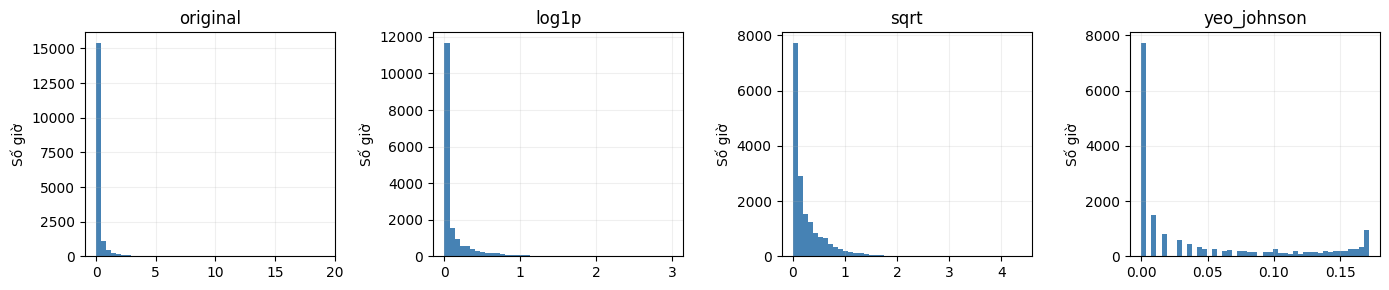

In [7]:
rain = weather.PRECTOTCORR.dropna()
transform_compare = pd.DataFrame({'original':rain,'log1p':np.log1p(rain),'sqrt':np.sqrt(rain)})
if len(rain)>2 and rain.nunique()>1:
    yj = PowerTransformer(method='yeo-johnson',standardize=False)
    transform_compare['yeo_johnson'] = yj.fit_transform(rain.to_frame()).ravel()
    print('Lambda Yeo–Johnson (toàn dữ liệu):',yj.lambdas_)
skew_report = transform_compare.agg(['min','median','max','skew']).T
display(skew_report.round(4))
fig,axes = plt.subplots(1,len(transform_compare.columns),figsize=(14,3))
for ax,c in zip(np.atleast_1d(axes),transform_compare):
    ax.hist(transform_compare[c],bins=45,color='steelblue'); ax.set_title(c); ax.set_ylabel('Số giờ')
plt.tight_layout(); plt.show()
decision('transform','PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN','log1p cho bản biến đổi','Không âm; giảm ảnh hưởng đuôi, giữ riêng giá trị gốc')


### 7. Rời rạc hóa: cut và qcut (slide 82)
`cut` dùng ngưỡng cố định; `qcut` tìm ngưỡng theo dữ liệu để tạo nhóm gần bằng nhau. Nhiều giờ mưa bằng 0 làm phân vị trùng, nên minh họa qcut trên nhiệt độ. Ngưỡng 0,1 mm/giờ dưới đây là **quy ước của bài thực hành**, không phải phân loại cảnh báo khí tượng.

Ordinal chỉ dùng cho nhóm nhiệt độ có thứ tự; giờ, tháng, hướng gió có tính chu kỳ, không gán thứ tự tuyến tính để thay sin/cos. Binning dùng minh họa, không thay cột nhiệt độ liên tục trong bản chính.


In [8]:
binned = weather[['timestamp','T2M','PRECTOTCORR']].copy()
binned['temp_band'] = pd.cut(weather.T2M,[-np.inf,20,30,np.inf],labels=['low','middle','high'],right=False)
binned['temp_band_ordinal'] = binned.temp_band.map({'low':0,'middle':1,'high':2}).astype('Int64')
if weather.T2M.nunique()>1:
    binned['temp_quantile'], qcut_edges = pd.qcut(weather.T2M,q=4,duplicates='drop',retbins=True)
else:
    binned['temp_quantile'] = 'Không đủ biến thiên'
    qcut_edges = np.array([])
binned['rain_now'] = (weather.PRECTOTCORR>=0.1).astype('Int64').mask(weather.PRECTOTCORR.isna())
print('Ngưỡng qcut nhiệt độ:',qcut_edges)
display(binned.groupby('temp_band',observed=True).agg(n=('T2M','count'),min_T=('T2M','min'),max_T=('T2M','max')))
display(binned.temp_quantile.value_counts(sort=False).to_frame('n'))


Ngưỡng qcut nhiệt độ: [ 3.29 19.94 25.29 28.14 41.27]


,n,min_T,max_T
temp_band,,,
low,4433,3.29,19.99
middle,10414,20.00,29.99
high,2697,30.00,41.27


,n
temp_quantile,
"(3.289, 19.94]",4394
"(19.94, 25.29]",4385
"(25.29, 28.14]",4384
"(28.14, 41.27]",4381


### 8. Tạo đặc trưng chu kỳ và đóng gói Pipeline (slide 83–86, 102)
- `WD2M → wind_sin, wind_cos`: 359° gần 0°, không còn bước nhảy giả ở ranh giới.
- Giờ/tháng → sin/cos để mô tả nhịp ngày và năm; dùng giờ Việt Nam.
- `season` → one-hot với thứ tự mùa khai báo rõ. Phân mùa tháng 3–5/6–8/9–11/12–2 là quy ước lịch, không phải nhãn mùa khí tượng được xác minh.
- `city`, tọa độ và `source_row` không vào X: địa điểm hằng và thông tin truy vết không phải tín hiệu dự báo tại một điểm.

Pipeline: đặc trưng xác định → `ColumnTransformer` → median imputation + RobustScaler cho biến liên tục, passthrough biến chu kỳ sau điền thiếu, OneHotEncoder cho mùa. Cột hoàn toàn thiếu sẽ bị chặn. Median được fit trên toàn dữ liệu **chỉ để thực hành W5**; cột nguyên bản vẫn giữ NaN, có bảng ghi từng ô điền trong ma trận biến đổi. Không áp dụng cho nhãn tương lai.


In [9]:
NUM_COLS = ['T2M','RH2M','PS','PRECTOTCORR_log1p','WS2M_log1p','ALLSKY_SFC_SW_DWN_log1p']
CYCLE_COLS = ['wind_sin','wind_cos','hour_sin','hour_cos','month_sin','month_cos']
CAT_COLS = ['season']
class WeatherFeatures(BaseEstimator,TransformerMixin):
    def fit(self,X,y=None): return self
    def transform(self,X):
        out = X[['T2M','RH2M','PS']].copy()
        for c in ['PRECTOTCORR','WS2M','ALLSKY_SFC_SW_DWN']:
            out[c+'_log1p'] = np.log1p(X[c])
        out['wind_sin'] = np.sin(np.deg2rad(X.WD2M))
        out['wind_cos'] = np.cos(np.deg2rad(X.WD2M))
        hour = X.timestamp.dt.hour
        month = X.timestamp.dt.month
        out['hour_sin'],out['hour_cos'] = np.sin(2*np.pi*hour/24),np.cos(2*np.pi*hour/24)
        out['month_sin'],out['month_cos'] = np.sin(2*np.pi*(month-1)/12),np.cos(2*np.pi*(month-1)/12)
        out['season'] = month.map({12:'winter',1:'winter',2:'winter',3:'spring',4:'spring',5:'spring',
                                  6:'summer',7:'summer',8:'summer',9:'autumn',10:'autumn',11:'autumn'})
        return out

def make_preprocessor():
    numeric = Pipeline([('impute',SimpleImputer(strategy='median',add_indicator=True)),('scale',RobustScaler())])
    cyclical = Pipeline([('impute',SimpleImputer(strategy='median',add_indicator=True))])
    # sparse_output dùng trong scikit-learn >= 1.2.
    encoding = OneHotEncoder(categories=[['spring','summer','autumn','winter']],drop='first',
                             handle_unknown='ignore',sparse_output=False)
    columns = ColumnTransformer([('numeric',numeric,NUM_COLS),('cycle',cyclical,CYCLE_COLS),
                                 ('category',encoding,CAT_COLS)],remainder='drop')
    return Pipeline([('features',WeatherFeatures()),('columns',columns)])

def run_w5(frame,metadata):
    validated,clean_log = prepare_weather(frame,metadata)
    feature_frame = WeatherFeatures().fit_transform(validated)
    all_missing = feature_frame[NUM_COLS+CYCLE_COLS].isna().all()
    if all_missing.any(): raise ValueError(f'Cột hoàn toàn thiếu: {list(all_missing.index[all_missing])}')
    pipe = make_preprocessor()
    matrix = pipe.fit_transform(validated)
    names = pipe.named_steps['columns'].get_feature_names_out()
    X = pd.DataFrame(matrix,columns=names,index=validated.index)
    if not np.isfinite(X.to_numpy()).all(): raise ValueError('Ma trận vẫn có NaN/inf.')
    return validated,feature_frame,X,pipe,clean_log

# Một lệnh gọi quy trình raw → ma trận đã xử lý; Run All bổ sung báo cáo và xuất tệp.
validated, engineered, X_processed, preprocessing_pipeline, _ = run_w5(raw,meta)
pd.testing.assert_frame_equal(validated,weather)
print('Đầu vào khí tượng:',len(FEATURES),'biến | Ma trận sau biến đổi:',X_processed.shape)
display(engineered.head(3)); display(X_processed.head(3))
imputation_rows=[]
for group,cols in [('numeric',NUM_COLS),('cycle',CYCLE_COLS)]:
    imputer=preprocessing_pipeline.named_steps['columns'].named_transformers_[group].named_steps['impute']
    for c,median in zip(cols,imputer.statistics_):
        for i in engineered.index[engineered[c].isna()]:
            imputation_rows.append({'source_row':weather.at[i,'source_row'],'timestamp':weather.at[i,'timestamp'],
                'feature':c,'before':'NaN','after':median,'reason':'Median toàn dữ liệu; chỉ bản biến đổi W5'})
imputation_log=pd.DataFrame(imputation_rows,columns=['source_row','timestamp','feature','before','after','reason'])
decision('encoding','WD2M/hour/month/season','sin-cos và one-hot','Tôn trọng chu kỳ và biến phân loại')
decision('imputation','X_processed','Median toàn dữ liệu + missing indicator','Phục vụ EDA; giữ NaN trong weather_validated')


Đầu vào khí tượng: 7 biến | Ma trận sau biến đổi: (17544, 15)


,T2M,RH2M,PS,PRECTOTCORR_log1p,WS2M_log1p,ALLSKY_SFC_SW_DWN_log1p,wind_sin,wind_cos,hour_sin,hour_cos,month_sin,month_cos,season
0,9.75,83.01,101.62,0.0,1.141033,4.773055,0.305695,0.952129,0.965926,-0.258819,0.0,1.0,winter
1,12.01,71.80,101.66,0.0,1.324419,5.701213,0.500000,0.866025,0.866025,-0.500000,0.0,1.0,winter
2,14.32,64.32,101.66,0.0,1.332366,6.164893,0.649448,0.760406,0.707107,-0.707107,0.0,1.0,winter


,numeric__T2M,numeric__RH2M,numeric__PS,numeric__PRECTOTCORR_log1p,numeric__WS2M_log1p,numeric__ALLSKY_SFC_SW_DWN_log1p,cycle__wind_sin,cycle__wind_cos,cycle__hour_sin,cycle__hour_cos,cycle__month_sin,cycle__month_cos,category__season_summer,category__season_autumn,category__season_winter
0,-1.895122,-0.171137,1.376068,-0.07594,0.421634,0.523574,0.305695,0.952129,0.965926,-0.258819,0.0,1.0,0.0,0.0,1.0
1,-1.619512,-0.668145,1.410256,-0.07594,0.765681,0.689870,0.500000,0.866025,0.866025,-0.500000,0.0,1.0,0.0,0.0,1.0
2,-1.337805,-0.999778,1.410256,-0.07594,0.780590,0.772947,0.649448,0.760406,0.707107,-0.707107,0.0,1.0,0.0,0.0,1.0


### 9. So sánh MinMax, Standard, Robust (slide 76–80)
So sánh trên cùng bản liên tục đã log và điền thiếu. MinMax đưa dữ liệu hiện tại về [0,1]; Standard có mean≈0, std≈1; Robust có median≈0, IQR≈1 **khi IQR khác 0**. Với cột IQR=0, sklearn dùng hệ số dự phòng nên không thể khẳng định IQR sau scale bằng 1.

RobustScaler không xóa outlier, không làm dữ liệu thành phân phối chuẩn. PCA cần scale; cây quyết định/Random Forest thường không cần. Bản chính dùng Robust để minh họa giữ các đuôi thật; đây chưa phải lựa chọn tối ưu đã kiểm nghiệm.


,scaler,feature,min,max,mean,std_ddof0,median,IQR
0,MinMax,T2M,0.000,1.000,0.546,0.161,0.579,0.216
1,MinMax,RH2M,0.000,1.000,0.764,0.194,0.819,0.311
2,MinMax,PS,0.000,1.000,0.536,0.149,0.520,0.235
3,MinMax,PRECTOTCORR_log1p,0.000,1.000,0.044,0.090,0.003,0.044
4,MinMax,WS2M_log1p,0.000,1.000,0.370,0.141,0.359,0.211
5,MinMax,ALLSKY_SFC_SW_DWN_log1p,0.000,1.000,0.389,0.399,0.268,0.809
6,Standard,T2M,-3.394,2.825,-0.000,1.000,0.208,1.343
7,Standard,RH2M,-3.938,1.218,-0.000,1.000,0.284,1.606
8,Standard,PS,-3.588,3.112,0.000,1.000,-0.104,1.574
9,Standard,PRECTOTCORR_log1p,-0.486,10.586,-0.000,1.000,-0.449,0.484


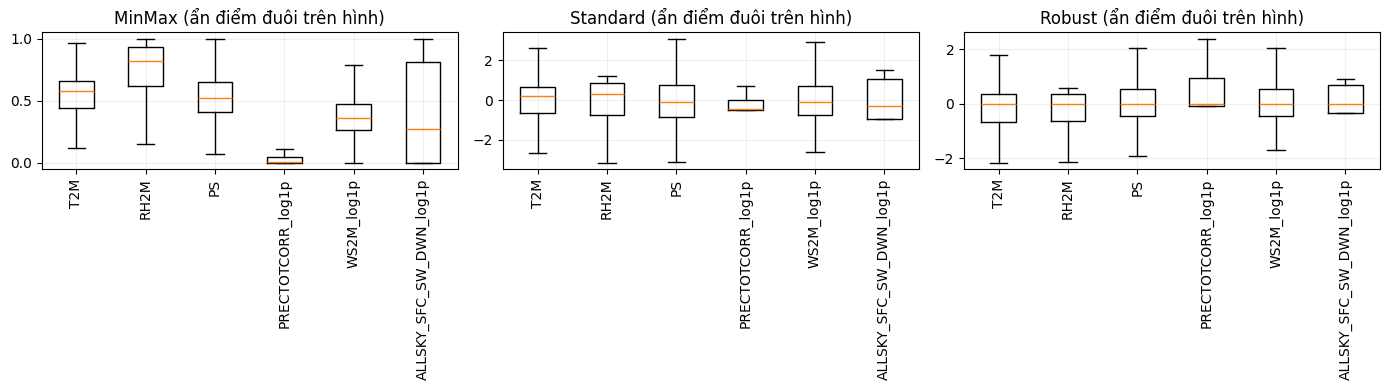

In [10]:
scale_base = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(engineered[NUM_COLS]),columns=NUM_COLS)
scaled_versions = {}
scale_stats=[]
for name,scaler in [('MinMax',MinMaxScaler()),('Standard',StandardScaler()),('Robust',RobustScaler())]:
    a = pd.DataFrame(scaler.fit_transform(scale_base),columns=NUM_COLS)
    scaled_versions[name]=a
    for c in NUM_COLS:
        scale_stats.append({'scaler':name,'feature':c,'min':a[c].min(),'max':a[c].max(),
            'mean':a[c].mean(),'std_ddof0':a[c].std(ddof=0),'median':a[c].median(),
            'IQR':a[c].quantile(.75)-a[c].quantile(.25)})
scale_report=pd.DataFrame(scale_stats)
display(scale_report.round(3))
fig,axes=plt.subplots(1,3,figsize=(14,4))
for ax,(name,a) in zip(axes,scaled_versions.items()):
    ax.boxplot([a[c] for c in NUM_COLS],tick_labels=NUM_COLS,showfliers=False)
    ax.tick_params(axis='x',rotation=90); ax.set_title(name+' (ẩn điểm đuôi trên hình)')
plt.tight_layout(); plt.show()
decision('scaling',','.join(NUM_COLS),'RobustScaler','Giữ thời tiết cực đoan; phép so sánh khám phá')


### 10. Giảm số cột: hằng số và tương quan (slide 88–89)
Cột hằng không phân biệt các giờ. Phương sai gần 0 phụ thuộc thang đo nên bảng dùng tỷ lệ giá trị phổ biến nhất để **rà soát**, không tự loại cờ hiếm quan trọng. `city/latitude/longitude` chỉ được giữ làm metadata.

Đề xuất giảm tương quan: xét |r| > 0,95 giữa các biến liên tục; mỗi cặp chỉ loại biến sau khi biến trước vẫn được giữ. Không đưa target vào tính chọn biến; không xóa tự động biến chu kỳ hoặc cờ hiếm. Đây là bản giảm riêng để so sánh, giữ nguyên bản đầy đủ.


In [11]:
constant_cols=[c for c in X_processed if X_processed[c].nunique(dropna=False)<=1]
near_constant=pd.DataFrame({'top_value_ratio':X_processed.apply(lambda s:s.value_counts(normalize=True,dropna=False).iloc[0]),
                            'variance':X_processed.var(ddof=0)})
display(near_constant.sort_values('top_value_ratio',ascending=False))
corr=scale_base.corr().abs()
keep=[]; correlated=[]
for c in NUM_COLS:
    related=[k for k in keep if pd.notna(corr.loc[c,k]) and corr.loc[c,k]>.95]
    if related: correlated.append({'drop_feature':c,'keep_feature':related[0],'abs_r':corr.loc[c,related[0]]})
    else: keep.append(c)
corr_proposals=pd.DataFrame(correlated,columns=['drop_feature','keep_feature','abs_r'])
drop_proposed=[f'numeric__{r["drop_feature"]}' for r in correlated]
X_reduced=X_processed.drop(columns=list(set(constant_cols+drop_proposed)),errors='ignore')
print('Cột hằng:',constant_cols,'| trước/sau:',X_processed.shape[1],X_reduced.shape[1])
display(corr_proposals)
decision('reduction','X_reduced','Bản đề xuất riêng: bỏ hằng và tương quan >0.95','Chưa đánh giá ảnh hưởng tới dự báo')


Cột hằng: [] | trước/sau: 15 15


,top_value_ratio,variance
category__season_winter,0.752394,0.186297
category__season_autumn,0.751026,0.186986
category__season_summer,0.748290,0.188352
numeric__ALLSKY_SFC_SW_DWN_log1p,0.478226,0.242927
numeric__PRECTOTCORR_log1p,0.440093,4.271549
cycle__month_cos,0.166895,0.500329
cycle__month_sin,0.160055,0.499650
cycle__hour_cos,0.083333,0.500000
cycle__hour_sin,0.083333,0.500000
numeric__RH2M,0.036423,0.387812


,drop_feature,keep_feature,abs_r


### 11. PCA: giữ ít nhất 95% phương sai (slide 91)
PCA chỉ minh họa trên các biến liên tục sau log/median, **StandardScaler trước PCA**. Không đưa season, mã dòng, tọa độ hay target vào. 95% phương sai không có nghĩa 95% độ chính xác dự báo. Thành phần PC là tổ hợp các biến, mất cách đọc bằng °C/mm; dữ liệu PCA xuất riêng, không thay bộ chính.


,component,explained_ratio,cumulative_ratio
0,PC1,0.386971,0.386971
1,PC2,0.301209,0.688180
2,PC3,0.163107,0.851287
3,PC4,0.096029,0.947316
4,PC5,0.037569,0.984885


,PC1,PC2,PC3,PC4,PC5
T2M,0.528,-0.364,-0.246,0.115,-0.025
RH2M,-0.437,-0.441,0.202,0.330,0.668
PS,-0.331,0.592,0.173,-0.269,0.122
PRECTOTCORR_log1p,0.156,-0.380,0.718,-0.553,-0.098
WS2M_log1p,0.313,0.306,0.593,0.667,-0.106
ALLSKY_SFC_SW_DWN_log1p,0.547,0.290,-0.040,-0.234,0.720


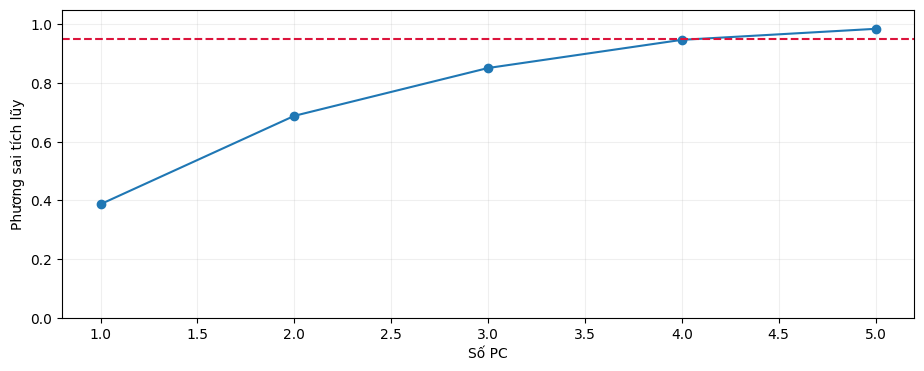

In [12]:
pca_cols=[c for c in scale_base if scale_base[c].nunique()>1]
pca_report=pd.DataFrame(); pca_loadings=pd.DataFrame(); X_pca=pd.DataFrame(index=weather.index)
if len(pca_cols)>=2 and len(scale_base)>=3:
    pca_scaler=StandardScaler()
    pca_input=pca_scaler.fit_transform(scale_base[pca_cols])
    pca=PCA(n_components=.95,svd_solver='full')
    scores=pca.fit_transform(pca_input)
    X_pca=pd.DataFrame(scores,columns=[f'PC{i+1}' for i in range(scores.shape[1])])
    pca_report=pd.DataFrame({'component':X_pca.columns,'explained_ratio':pca.explained_variance_ratio_,
                             'cumulative_ratio':np.cumsum(pca.explained_variance_ratio_)})
    pca_loadings=pd.DataFrame(pca.components_.T,index=pca_cols,columns=X_pca.columns)
    display(pca_report); display(pca_loadings.round(3))
    fig,ax=plt.subplots()
    ax.plot(np.arange(1,len(pca_report)+1),pca_report.cumulative_ratio,'o-')
    ax.axhline(.95,color='crimson',ls='--'); ax.set(xlabel='Số PC',ylabel='Phương sai tích lũy',ylim=(0,1.05))
    plt.show()
else:
    print('Không đủ biến thiên để minh họa PCA.')
decision('PCA',','.join(pca_cols),'StandardScaler + PCA 95%, xuất riêng','Giảm chiều cho minh họa, không suy ra chất lượng dự báo')


### 12. Giảm số dòng: tổng hợp ngày và cửa sổ thời gian (slide 88–90, 100)
Dữ liệu là chuỗi thời gian nên không lấy mẫu ngẫu nhiên để tạo chuỗi huấn luyện. Chọn cửa sổ 7 ngày liên tục cho biểu đồ.

Bảng ngày phục vụ EDA: nhiệt độ trung bình, mưa tích lũy theo 24 khoảng giờ (mm/giờ × 1 giờ), độ ẩm trung bình. Chỉ công bố tổng mưa ngày đầy đủ khi có đúng 24 giá trị; tổng quan sát một phần vẫn có cột riêng. Ngày đầu/cuối có thể thiếu do UTC → giờ Việt Nam. Không ghép tổng mưa cả ngày trở lại từng giờ để dự báo trong ngày — đó là sử dụng thông tin tương lai.


Giờ → ngày: 17544 → 732 | ngày mưa đầy đủ: 730


,date,rows,temperature_mean_C,temperature_count,rain_count,rain_observed_sum_mm,humidity_mean_pct,complete_rain_day,rain_total_mm
0,2023-01-01 00:00:00+07:00,17,15.816471,17,17,0.00,67.785294,False,NaN
1,2023-01-02 00:00:00+07:00,24,13.969583,24,24,0.20,82.958333,True,0.20
2,2023-01-03 00:00:00+07:00,24,14.540000,24,24,0.66,75.161250,True,0.66
3,2023-01-04 00:00:00+07:00,24,15.585833,24,24,0.00,80.612500,True,0.00
4,2023-01-05 00:00:00+07:00,24,16.738750,24,24,0.00,86.305833,True,0.00


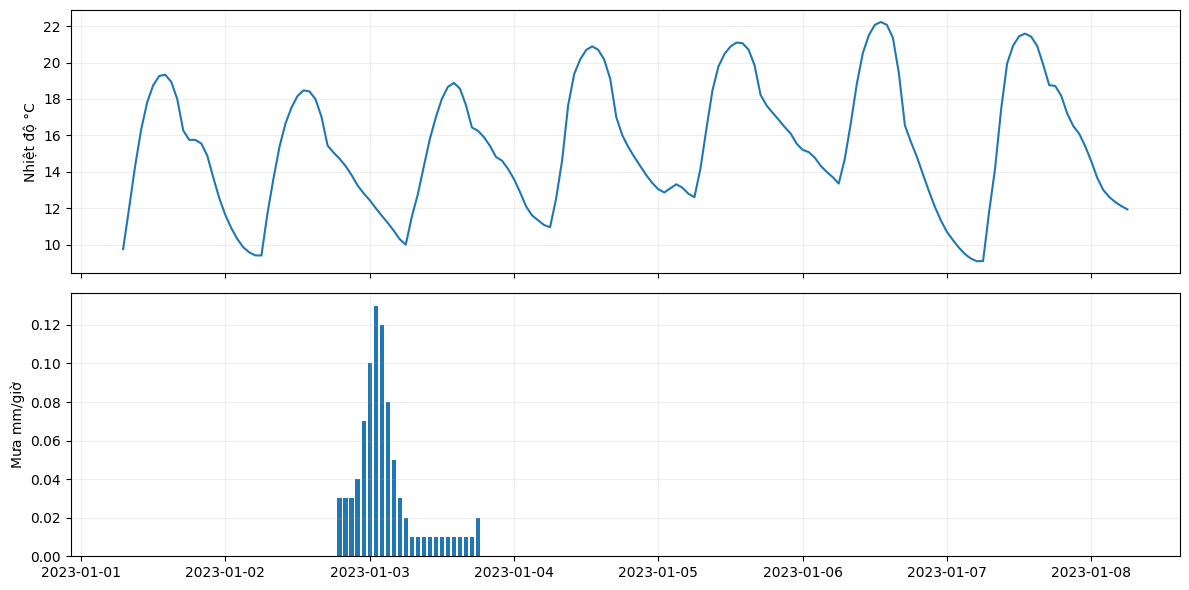

In [13]:
daily=(weather.assign(date=weather.timestamp.dt.floor('D')).groupby('date').agg(
    rows=('timestamp','size'),temperature_mean_C=('T2M','mean'),temperature_count=('T2M','count'),
    rain_count=('PRECTOTCORR','count'),rain_observed_sum_mm=('PRECTOTCORR',lambda s:s.sum(min_count=1)),
    humidity_mean_pct=('RH2M','mean')).reset_index())
daily['complete_rain_day']=daily.rows.eq(24)&daily.rain_count.eq(24)
daily['rain_total_mm']=daily.rain_observed_sum_mm.where(daily.complete_rain_day)
window=weather.loc[weather.timestamp<weather.timestamp.min()+pd.Timedelta(days=7)]
print('Giờ → ngày:',len(weather),'→',len(daily),'| ngày mưa đầy đủ:',int(daily.complete_rain_day.sum()))
display(daily.head())
fig,axes=plt.subplots(2,1,figsize=(12,6),sharex=True)
axes[0].plot(window.timestamp,window.T2M); axes[0].set_ylabel('Nhiệt độ °C')
axes[1].bar(window.timestamp,window.PRECTOTCORR,width=.03); axes[1].set_ylabel('Mưa mm/giờ')
plt.tight_layout(); plt.show()


### 13. Phần mở rộng dự án: lag và target trước 1 giờ — chưa chia tập
Không phải yêu cầu bắt buộc của slide W5, nhưng kết nối với mục tiêu dự án. Tại thời điểm t, giả định số liệu giờ t đã sẵn có: dùng X(t) và lag t−1h/t−24h; target lấy từ **đúng t+1h**. Dùng tra cứu theo timestamp để không nhầm “dòng tiếp theo” thành “giờ tiếp theo” khi thiếu giờ.

`target_temperature_1h`: °C; `target_rainfall_1h`: mm/giờ; `target_rain_1h`: 1 nếu mưa ≥0,1 mm/giờ, 0 nếu ít hơn. Không điền thiếu nhãn. Lag khởi đầu và target cuối chuỗi được giữ NaN với cột đánh dấu. `features_1h_unscaled.csv` là bản chưa fit scaler cho giai đoạn mô hình hóa sau này; không đưa cột target vào X. NASA lịch sử không bảo đảm khả năng cung cấp tức thời ở ngoài thực tế.


In [14]:
features_1h=weather[['timestamp','city','source_row',*FEATURES]].copy()
lookup=weather.set_index('timestamp')
for c in ['T2M','PRECTOTCORR','RH2M','PS']:
    for lag in [1,24]:
        features_1h[f'{c}_lag_{lag}h']=lookup[c].reindex(weather.timestamp-pd.Timedelta(hours=lag)).to_numpy()
for c,name in [('T2M','target_temperature_1h'),('PRECTOTCORR','target_rainfall_1h')]:
    features_1h[name]=lookup[c].reindex(weather.timestamp+pd.Timedelta(hours=1)).to_numpy()
features_1h['target_rain_1h']=(features_1h.target_rainfall_1h>=.1).astype('Int64').mask(features_1h.target_rainfall_1h.isna())
features_1h['has_both_targets']=features_1h[['target_temperature_1h','target_rainfall_1h']].notna().all(axis=1)
lag_cols=[c for c in features_1h if '_lag_' in c]
features_1h['has_all_lags']=features_1h[lag_cols].notna().all(axis=1)
display(features_1h.tail(3))
print('Có đủ hai target:',int(features_1h.has_both_targets.sum()),'/',len(features_1h))


Có đủ hai target: 17543 / 17544


,timestamp,city,source_row,T2M,PRECTOTCORR,RH2M,PS,WS2M,WD2M,ALLSKY_SFC_SW_DWN,T2M_lag_1h,T2M_lag_24h,PRECTOTCORR_lag_1h,PRECTOTCORR_lag_24h,RH2M_lag_1h,RH2M_lag_24h,PS_lag_1h,PS_lag_24h,target_temperature_1h,target_rainfall_1h,target_rain_1h,has_both_targets,has_all_lags
17541,2025-01-01 04:00:00+07:00,Hanoi,17542,10.57,0.0,100.0,100.72,0.96,318.8,0.00,10.85,13.23,0.0,0.01,99.66,92.49,100.72,101.09,10.39,0.0,0,True,True
17542,2025-01-01 05:00:00+07:00,Hanoi,17543,10.39,0.0,100.0,100.75,0.95,321.4,0.00,10.57,12.95,0.0,0.00,100.00,92.32,100.72,101.17,10.33,0.0,0,True,True
17543,2025-01-01 06:00:00+07:00,Hanoi,17544,10.33,0.0,100.0,100.81,0.91,325.3,3.97,10.39,12.81,0.0,0.00,100.00,91.84,100.75,101.25,NaN,NaN,<NA>,False,True


### 14. Xuất dữ liệu, data dictionary và toàn bộ log (EX5.1, EX5.3)
Đầu ra tại `data/processed/w5/` và `reports/w5/`. Không lưu một mô hình dự báo đã huấn luyện. Pipeline được tái tạo bằng code trong notebook; tham số fit và phiên bản thư viện lưu ở `metadata.json`.

| Tệp chính | Mục đích |
|---|---|
| weather_validated.csv / weather_integrated.csv | Đơn vị gốc, có thể còn NaN; EDA và truy vết |
| X_transformed_all_data.csv | Log, điền thiếu, scale, encoding; chỉ phục vụ W5 |
| X_reduced_proposal.csv / X_pca_demo.csv | Phương án giảm chiều riêng |
| features_1h_unscaled.csv | Feature lag + target; chưa scale, chưa chia tập |
| daily_summary.csv | Tổng hợp ngày; không dùng thay chuỗi giờ |
| cleaning_log.csv / imputation_log.csv | Sửa ô đầu vào / điền ô trong bản biến đổi |
| transformation_log.csv | Lý do cho từng lựa chọn |
| merge_report.csv / merge_unmatched.csv | Số dòng, match rate và khóa không khớp |
| data_dictionary.csv / metadata.json | Diễn giải cột và thông số tái lập |

Các tệp X được kèm timestamp để nối đúng dòng, nhưng timestamp dạng chuỗi không phải cột số đưa trực tiếp vào mô hình. Raw bất biến tương ứng với tư tưởng giữ raw của ELT trong slide; đây chỉ là quy trình tệp cục bộ, không phải hệ thống data warehouse.


In [15]:
assert hashlib.sha256(INPUT.read_bytes()).hexdigest()==input_hash
assert hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()==raw_hash
assert not weather.duplicated(['city','timestamp']).any()
assert weather.timestamp.is_monotonic_increasing
assert len(X_processed)==len(weather)==len(features_1h)==len(integrated)
assert not any(c.startswith('target_') for c in X_processed)
OUT.mkdir(parents=True,exist_ok=True); REPORT.mkdir(parents=True,exist_ok=True)
def save_csv(frame,path,index=False): frame.to_csv(path,index=index,encoding='utf-8-sig')
def with_keys(frame):
    assert frame.index.equals(weather.index)
    return pd.concat([weather[['timestamp','city','source_row']],frame],axis=1)
for filename,frame in {
    'weather_validated.csv':weather,'weather_integrated.csv':integrated,
    'X_transformed_all_data.csv':with_keys(X_processed),'X_reduced_proposal.csv':with_keys(X_reduced),
    'X_pca_demo.csv':with_keys(X_pca),'features_1h_unscaled.csv':features_1h,
    'daily_summary.csv':daily,'weather_long.csv':long}.items(): save_csv(frame,OUT/filename)
merge_report=pd.DataFrame(merge_reports,columns=['source','rows_before','rows_right','rows_after','matched_rows','unmatched_rows','match_rate_pct'])
unmatched=pd.concat(unmatched_reports,ignore_index=True) if unmatched_reports else pd.DataFrame(columns=['city','timestamp','merge_source'])
for filename,frame in {'cleaning_log.csv':full_cleaning_log,'imputation_log.csv':imputation_log,
    'transformation_log.csv':pd.DataFrame(decisions),'merge_report.csv':merge_report,
    'merge_unmatched.csv':unmatched,'scaler_comparison.csv':scale_report,
    'skew_comparison.csv':skew_report.reset_index(names='transform'),
    'correlation_proposals.csv':corr_proposals,'pca_variance.csv':pca_report,
    'missing_hours.csv':pd.DataFrame({'timestamp':missing_hours})}.items(): save_csv(frame,REPORT/filename)
if not pca_loadings.empty: save_csv(pca_loadings,REPORT/'pca_loadings.csv',index=True)

base_meanings={'T2M':'Nhiệt độ 2 m','PRECTOTCORR':'Lượng mưa hiệu chỉnh theo giờ','RH2M':'Độ ẩm tương đối 2 m',
 'PS':'Áp suất bề mặt','WS2M':'Tốc độ gió 2 m','WD2M':'Hướng gió 2 m','ALLSKY_SFC_SW_DWN':'Bức xạ sóng ngắn'}
rows=[]
for c in features_1h:
    unit=units.get(c,''); meaning=base_meanings.get(c,c); role='metadata'
    if c in FEATURES: role='feature_original'
    if '_lag_' in c:
        base=c.split('_lag_')[0]; unit=units.get(base,''); role='feature_lag'; meaning=f'{base} tại t−'+c.split('_lag_')[1]
    if c.startswith('target_'):
        role='target'; meaning={'target_temperature_1h':'Nhiệt độ đúng t+1h',
            'target_rainfall_1h':'Lượng mưa đúng t+1h','target_rain_1h':'Mưa t+1h ≥ 0.1 mm/giờ'}[c]
        unit='C' if 'temperature' in c else ('mm/hour' if 'rainfall' in c else '0/1')
    rows.append({'dataset':'features_1h_unscaled','column':c,'meaning':meaning,'unit':unit,'role':role,'dtype':str(features_1h[c].dtype)})
for c in X_processed:
    meaning='Đặc trưng sau biến đổi; tên sau __ chỉ biến gốc/biến tạo'
    if 'missingindicator' in c: meaning='Cờ thiếu trước điền: 1=thiếu'
    elif c.startswith('numeric__'): meaning='Biến liên tục (log1p nếu ghi trong tên), median impute, RobustScaler'
    elif c.startswith('cycle__'): meaning='Sin/cos chu kỳ; điền median nếu thiếu, không scale'
    elif c.startswith('category__'): meaning='One-hot mùa; spring là nhóm tham chiếu'
    rows.append({'dataset':'X_transformed_all_data','column':c,'meaning':meaning,'unit':'không đơn vị',
                 'role':'feature_exploratory','dtype':str(X_processed[c].dtype)})
dictionary=pd.DataFrame(rows); save_csv(dictionary,REPORT/'data_dictionary.csv')
ct=preprocessing_pipeline.named_steps['columns']
num_fit=ct.named_transformers_['numeric']
metadata={'scope':'all_data_no_split','input_mode':INPUT_MODE,'input_file':str(INPUT.relative_to(ROOT)),
 'input_sha256':input_hash,'raw_sha256':raw_hash,'rows_input':len(raw),'rows_validated':len(weather),
 'timezone_output':'UTC+07:00','features_transformed':list(X_processed.columns),
 'median_numeric':dict(zip(NUM_COLS,num_fit.named_steps['impute'].statistics_.tolist())),
 'robust_center':num_fit.named_steps['scale'].center_.tolist(),'robust_scale':num_fit.named_steps['scale'].scale_.tolist(),
 'median_cycle':dict(zip(CYCLE_COLS,ct.named_transformers_['cycle'].named_steps['impute'].statistics_.tolist())),
 'qcut_edges':qcut_edges.tolist(),'rain_threshold_mm_per_hour':.1,'external_status':external_status,
 'external_source':EXTERNAL_SOURCE_NAME,'external_sha256':external_hash,
 'source_metadata_file':META_PATH.name if meta else None,
 'source_metadata_sha256':hashlib.sha256(META_PATH.read_bytes()).hexdigest() if meta else None,
 'missing_hours':len(missing_hours),'random_state':RANDOM_STATE,
 'versions':{'python':platform.python_version(),'pandas':pd.__version__,'numpy':np.__version__,'scikit_learn':sklearn.__version__}}
(REPORT/'metadata.json').write_text(json.dumps(metadata,ensure_ascii=False,indent=2,allow_nan=False),encoding='utf-8')
print('Đã xuất:',OUT.relative_to(ROOT),'và',REPORT.relative_to(ROOT))


Đã xuất: data/processed/w5 và reports/w5


### 15. Kết quả thực tế và gợi ý viết báo cáo W5
Cell sau tính kết luận từ dữ liệu chạy, không điền sẵn con số giả. Phần nhận xét cần nêu ý nghĩa kết quả, không chỉ chép bảng.


In [16]:
summary=f"""**Tóm tắt W5 — không chia train/test**
- {len(raw):,} dòng đầu vào → {len(weather):,} dòng sau kiểm tra; {len(missing_hours):,} giờ thiếu.
- Nhật ký làm sạch: {len(full_cleaning_log):,} thao tác; điền trong ma trận biến đổi: {len(imputation_log):,} ô.
- Ma trận biến đổi: {X_processed.shape[1]} cột; bản giảm đề xuất: {X_reduced.shape[1]} cột.
- PCA giữ {X_pca.shape[1]} PC từ {len(pca_cols)} biến liên tục có biến thiên.
- Tổng hợp được {len(daily)} ngày; {int(daily.complete_rain_day.sum())} ngày có đủ 24 giá trị mưa.
- {external_status}
- Chưa có huấn luyện/đánh giá mô hình. Các phép fit dùng toàn bộ dữ liệu chỉ cho W5/EDA.
"""
display(Markdown(summary)); display(merge_report)
(REPORT/'summary.md').write_text(summary,encoding='utf-8')


Out[0]: 503


**Tóm tắt W5 — không chia train/test**
- 17,544 dòng đầu vào → 17,544 dòng sau kiểm tra; 0 giờ thiếu.
- Nhật ký làm sạch: 0 thao tác; điền trong ma trận biến đổi: 0 ô.
- Ma trận biến đổi: 15 cột; bản giảm đề xuất: 15 cột.
- PCA giữ 5 PC từ 6 biến liên tục có biến thiên.
- Tổng hợp được 732 ngày; 730 ngày có đủ 24 giá trị mưa.
- Chưa có nguồn độc lập; chưa hoàn tất phần nguồn độc lập của EX5.2 nếu được yêu cầu.
- Chưa có huấn luyện/đánh giá mô hình. Các phép fit dùng toàn bộ dữ liệu chỉ cho W5/EDA.


,source,rows_before,rows_right,rows_after,matched_rows,unmatched_rows,match_rate_pct
0,NASA metadata,17544,1,17544,17544,0,100.0


**Câu hỏi tự nhận xét để nộp bài**
1. Độ lệch của mưa trước/sau log1p thay đổi thế nào? Những giờ bằng 0 còn hay mất?
2. Vì sao Robust không ép mọi giá trị về [0,1]? Tại sao scaling không sửa được dữ liệu sai?
3. Cột nào hằng hoặc tương quan cao? Nếu bảng đề xuất rỗng, giải thích vì sao giữ các biến.
4. Bao nhiêu PC đạt ít nhất 95% phương sai? Tại sao chưa thể nói mô hình dự báo chính xác hơn?
5. Với từng merge: khóa/grain là gì, bao nhiêu dòng trước/sau, tỷ lệ khớp? Nếu không khớp 0 dòng, báo cáo đúng 0.
6. Nêu rõ nguồn metadata cùng NASA và trạng thái nguồn độc lập; không báo EX5.2 hoàn tất với hai nhà cung cấp nếu chưa có.

**Checklist slide 104:** EX5.1 có pipeline và Run All từ raw; EX5.3 có processed + cleaning log + transformation log + dictionary. EX5.2 có minh họa tích hợp tệp metadata, mã ghép nguồn độc lập và báo cáo match rate; nếu yêu cầu nguồn độc lập thì cần bổ sung tệp thực tế ở mục 5.

**Giới hạn:** median của hướng gió sin/cos chỉ là cách tạo ma trận EDA hữu hạn, không dùng để khôi phục hướng gió vật lý. Bảng giờ thiếu chưa được tự chèn; lag/target vẫn đúng thời gian nhờ tra cứu timestamp. Các thông số học toàn bộ dữ liệu không được mang nguyên vào đánh giá dự báo sau này.
